# MEDA droplet routing — run all experiments

**Before you start:** Runtime → Change runtime type → **T4 GPU** (needed only for Experiment 4).

Run the cells from top to bottom. Results (figures + CSV files) are saved in `meda-routing/results/`.

## 1. Upload and unzip the project
Run this cell, then click **Choose Files** and pick `meda-routing.zip`.

In [1]:
from google.colab import files
up = files.upload()
!unzip -oq meda-routing.zip
%cd meda-routing
!ls

Saving meda-routing.zip to meda-routing.zip
/content/meda-routing
experiments  README.md	       run_experiments.ipynb
medaroute    requirements.txt  tests


## 2. Install libraries (about 1 minute)
Colab already has PyTorch; this adds Gymnasium and Stable-Baselines3.

In [2]:
!pip install -q gymnasium stable-baselines3
import torch; print("GPU available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.0 MB/s eta 0:00:00
GPU available: True


## 3. Experiment 1 — one task, both routers' paths

saved results/exp1_paths.png


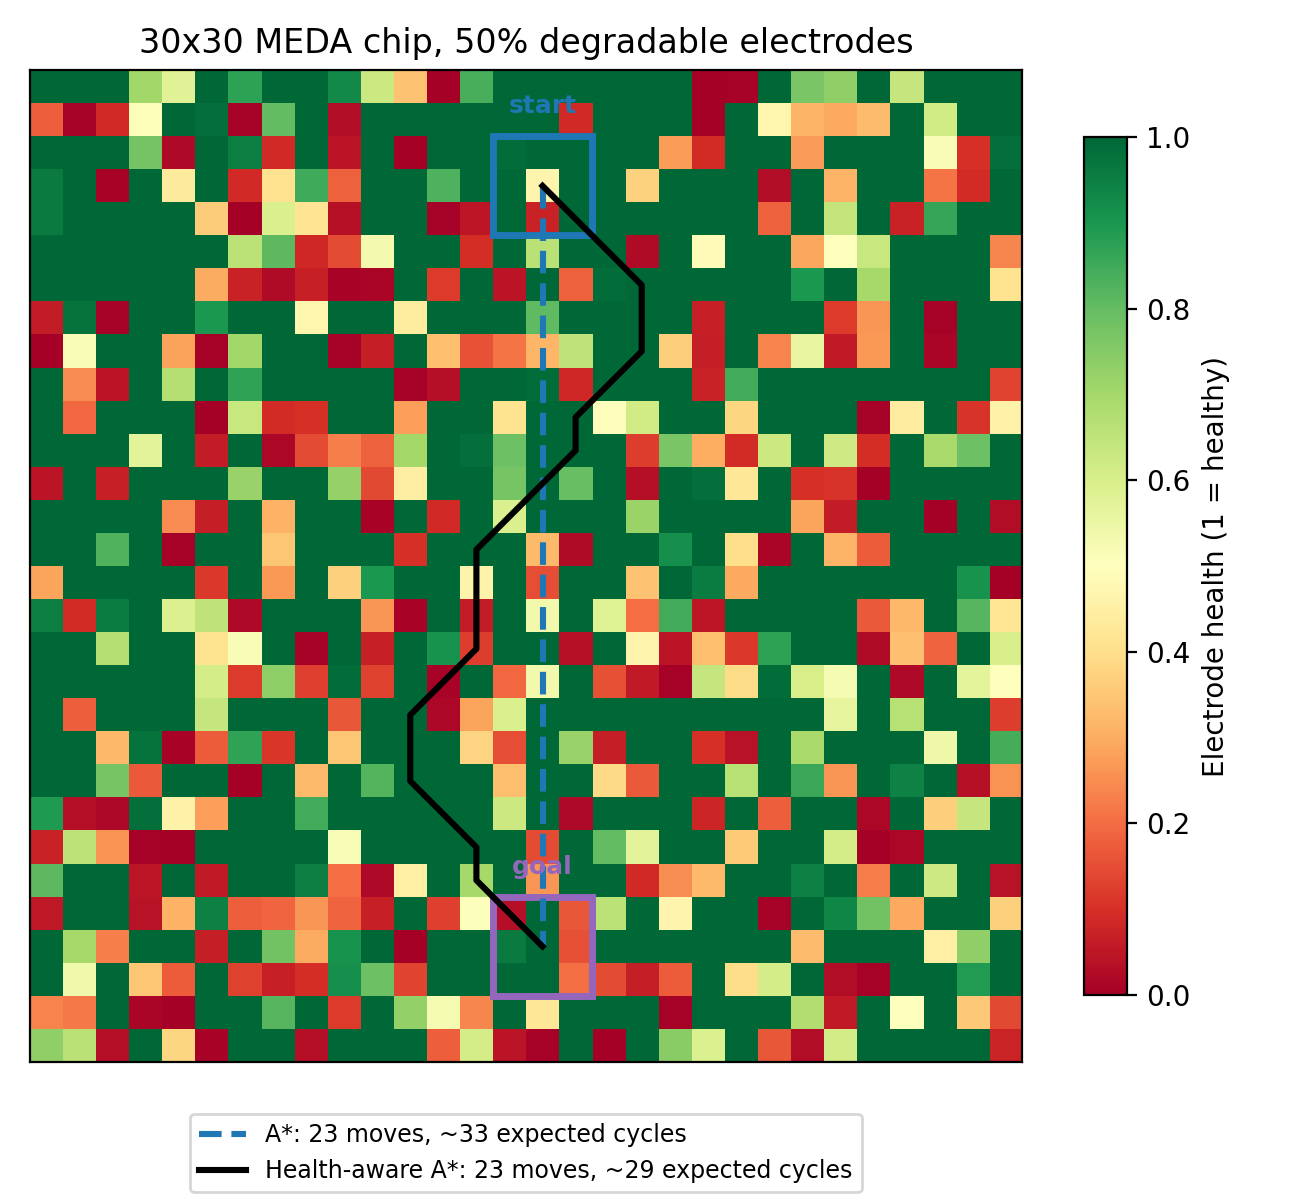

In [3]:
!python experiments/exp1_visualize.py
from IPython.display import Image, display
display(Image("results/exp1_paths.png", width=520))

## 4. Experiment 2 — success rate vs degradation level (~15 s)

  0%  A*               success=1.000  steps(success)=14.6  path=14.6
  0%  Health-aware A*  success=1.000  steps(success)=14.6  path=14.6
 10%  A*               success=0.994  steps(success)=15.4  path=14.4
 10%  Health-aware A*  success=1.000  steps(success)=14.8  path=14.4
 30%  A*               success=0.918  steps(success)=17.5  path=14.2
 30%  Health-aware A*  success=0.970  steps(success)=16.3  path=14.2
 50%  A*               success=0.634  steps(success)=19.2  path=14.3
 50%  Health-aware A*  success=0.848  steps(success)=18.6  path=14.4
 70%  A*               success=0.228  steps(success)=18.2  path=14.2
 70%  Health-aware A*  success=0.492  steps(success)=19.8  path=14.3
saved to results


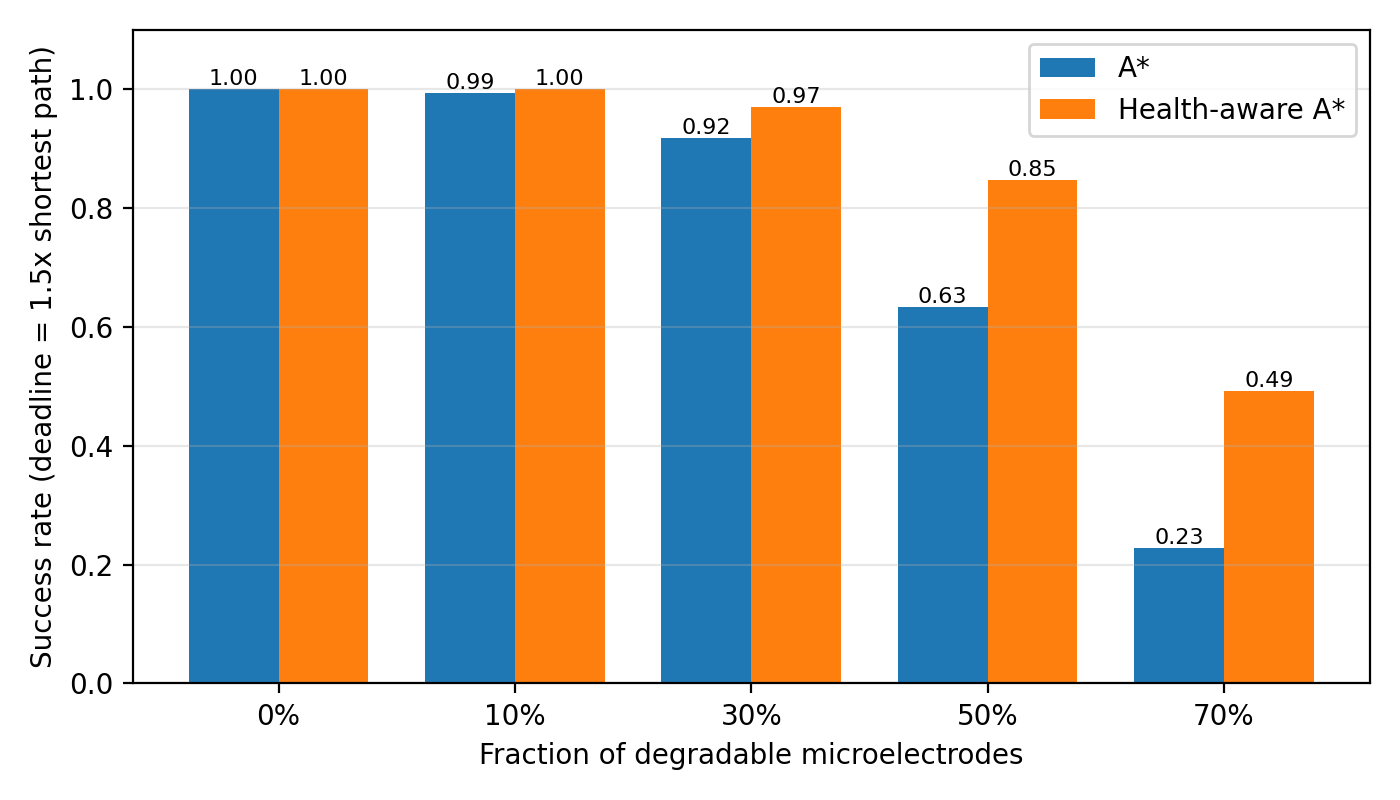

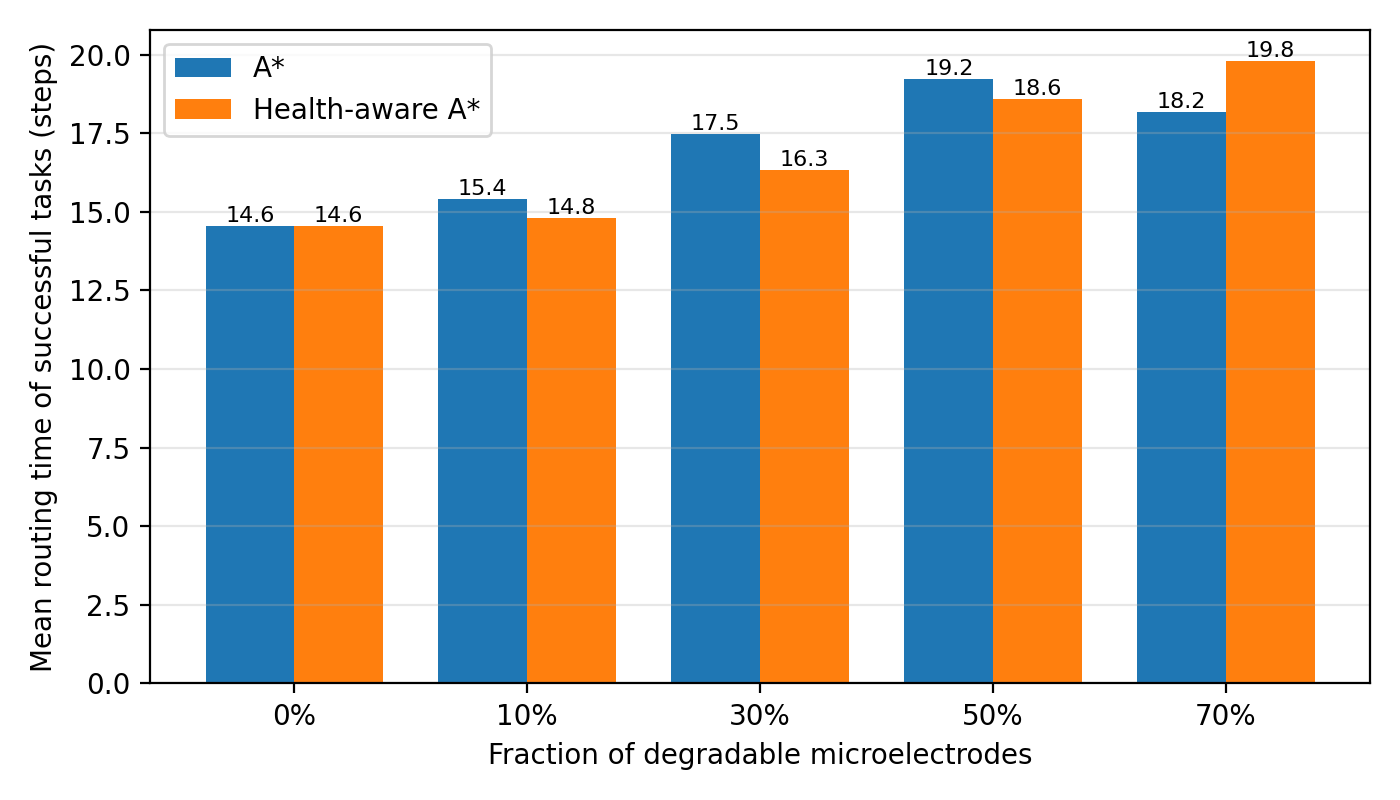

In [4]:
!python experiments/exp2_degradation_levels.py
display(Image("results/exp2_success.png", width=600))
display(Image("results/exp2_steps.png", width=600))

## 5. Experiment 3 — chip lifetime (~1–2 min)

chip 0  A*               first failure at task  223  overall success 0.521
chip 0  Health-aware A*  first failure at task  393  overall success 0.768
chip 1  A*               first failure at task  303  overall success 0.537
chip 1  Health-aware A*  first failure at task  378  overall success 0.726
chip 2  A*               first failure at task  255  overall success 0.443
chip 2  Health-aware A*  first failure at task  285  overall success 0.719
chip 3  A*               first failure at task  228  overall success 0.550
chip 3  Health-aware A*  first failure at task  679  overall success 0.793
chip 4  A*               first failure at task  205  overall success 0.465
chip 4  Health-aware A*  first failure at task  336  overall success 0.721
chip 5  A*               first failure at task  302  overall success 0.471
chip 5  Health-aware A*  first failure at task  304  overall success 0.698
chip 6  A*               first failure at task  207  overall success 0.481
chip 6  Health-aware A*  

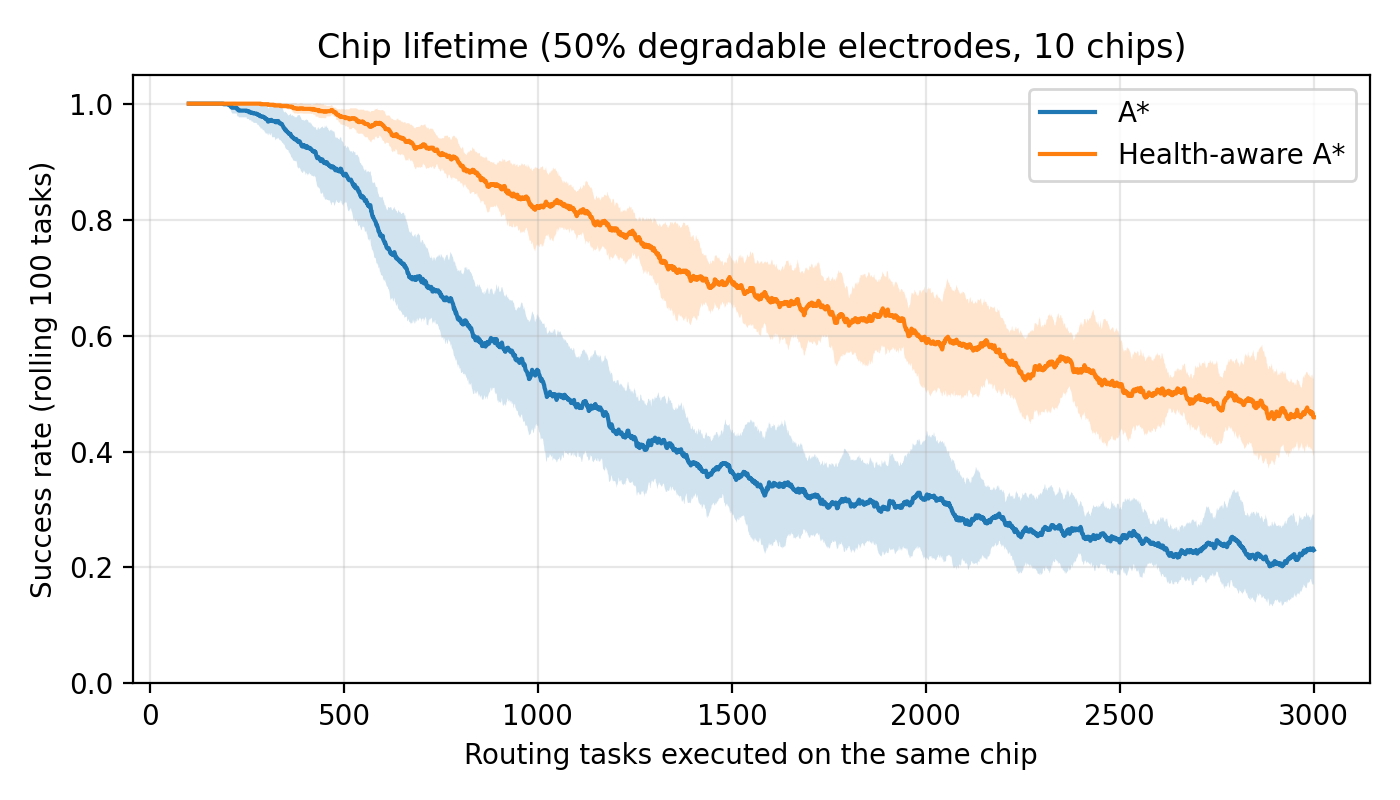

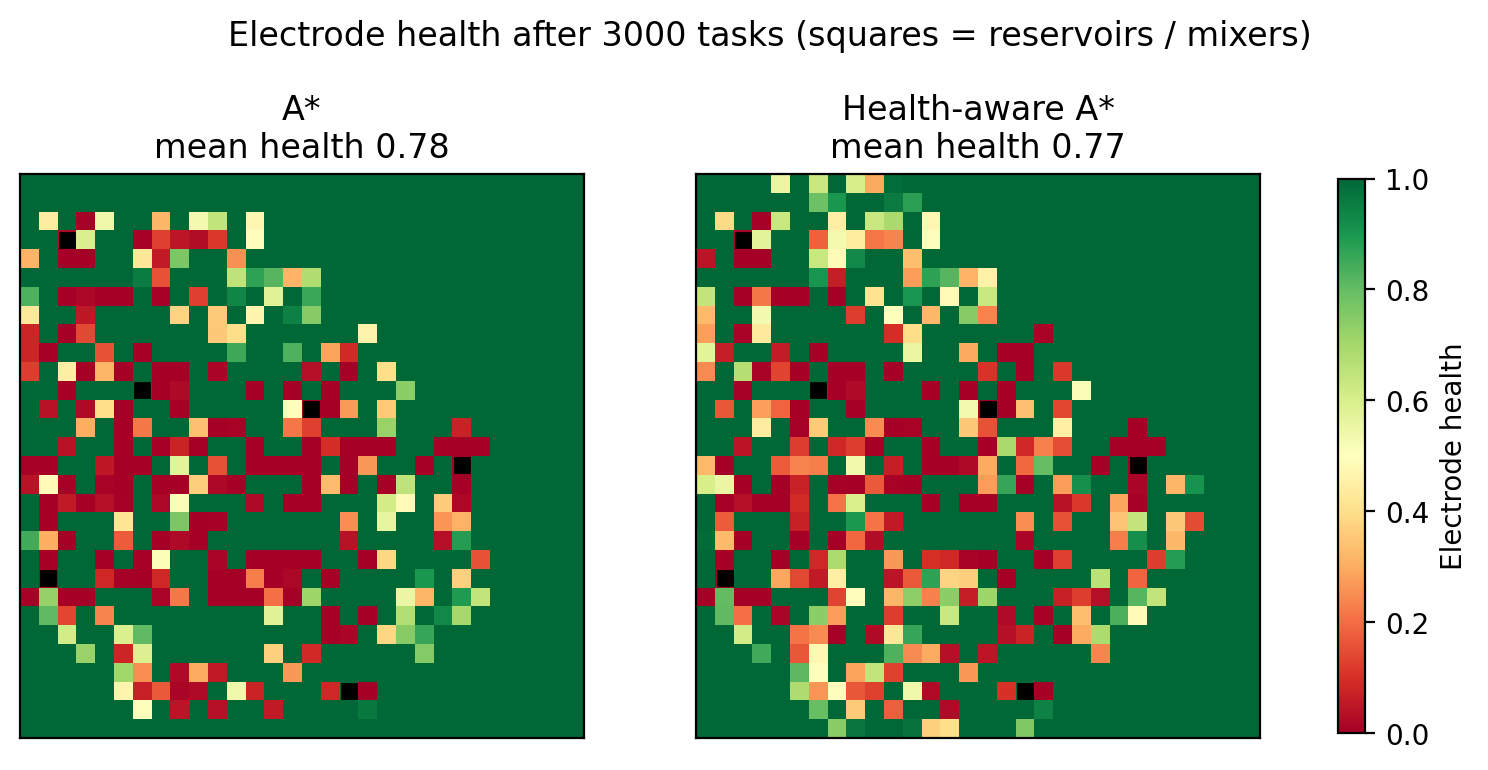

In [5]:
!python experiments/exp3_lifetime.py
display(Image("results/exp3_lifetime.png", width=600))
display(Image("results/exp3_health.png", width=700))

## 6. Experiment 4 — PPO agent, with vs without the health map

First a **quick test** (about 2 min) to check everything works — the agent will not have learned much yet.

In [6]:
!python experiments/exp4_ppo.py --timesteps 20000 --eval_episodes 100 --out results/smoke

2026-09-30 03:51:47.236097: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
device: cuda
/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com

**Full run.** Trains both agents. Start with 500k steps each; if the learning curve is still rising at the end, rerun with `--timesteps 1500000`.

Keep the browser tab open — Colab stops idle sessions. Models are saved, so you can re-evaluate later with `--eval_only`.

2026-09-30 03:52:26.720210: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
device: cuda
/usr/local/lib/python3.13/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com

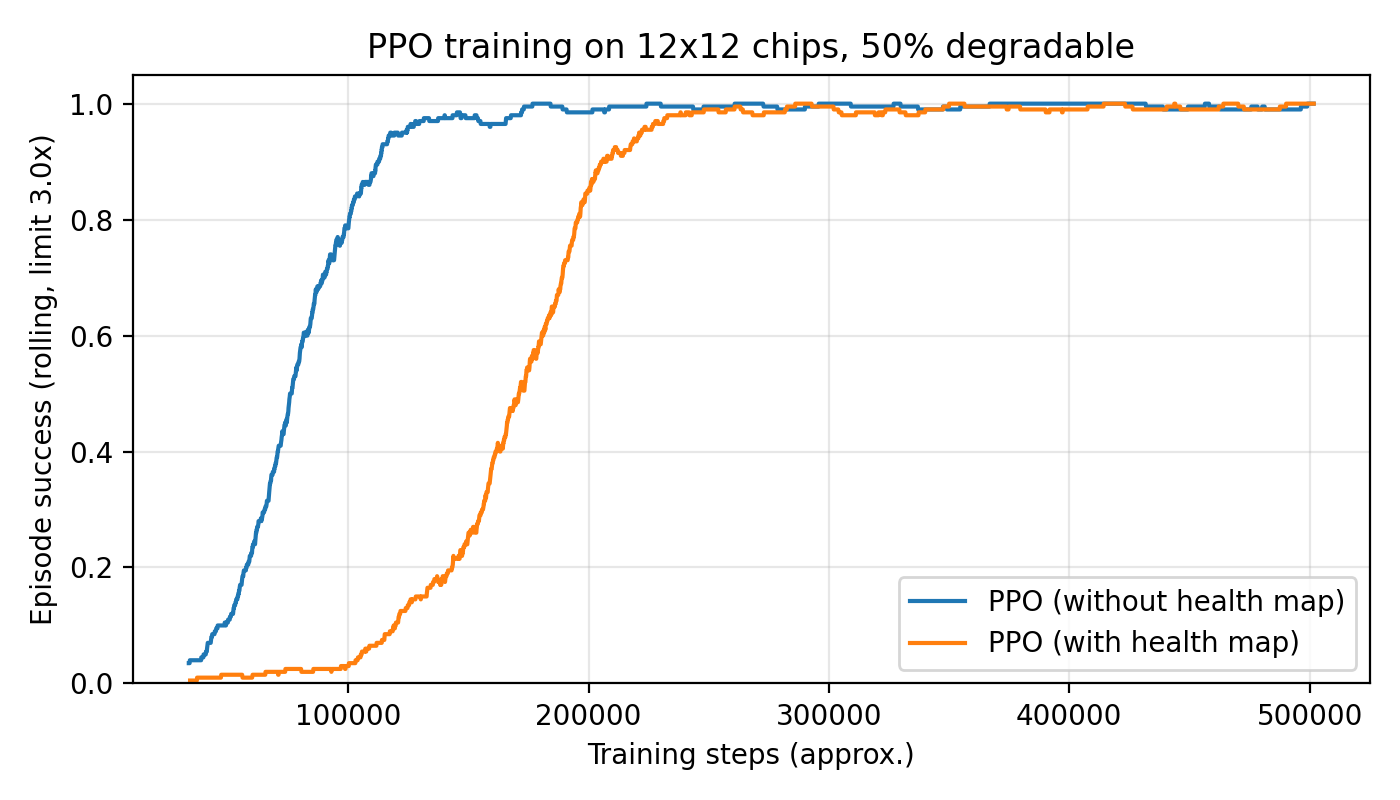

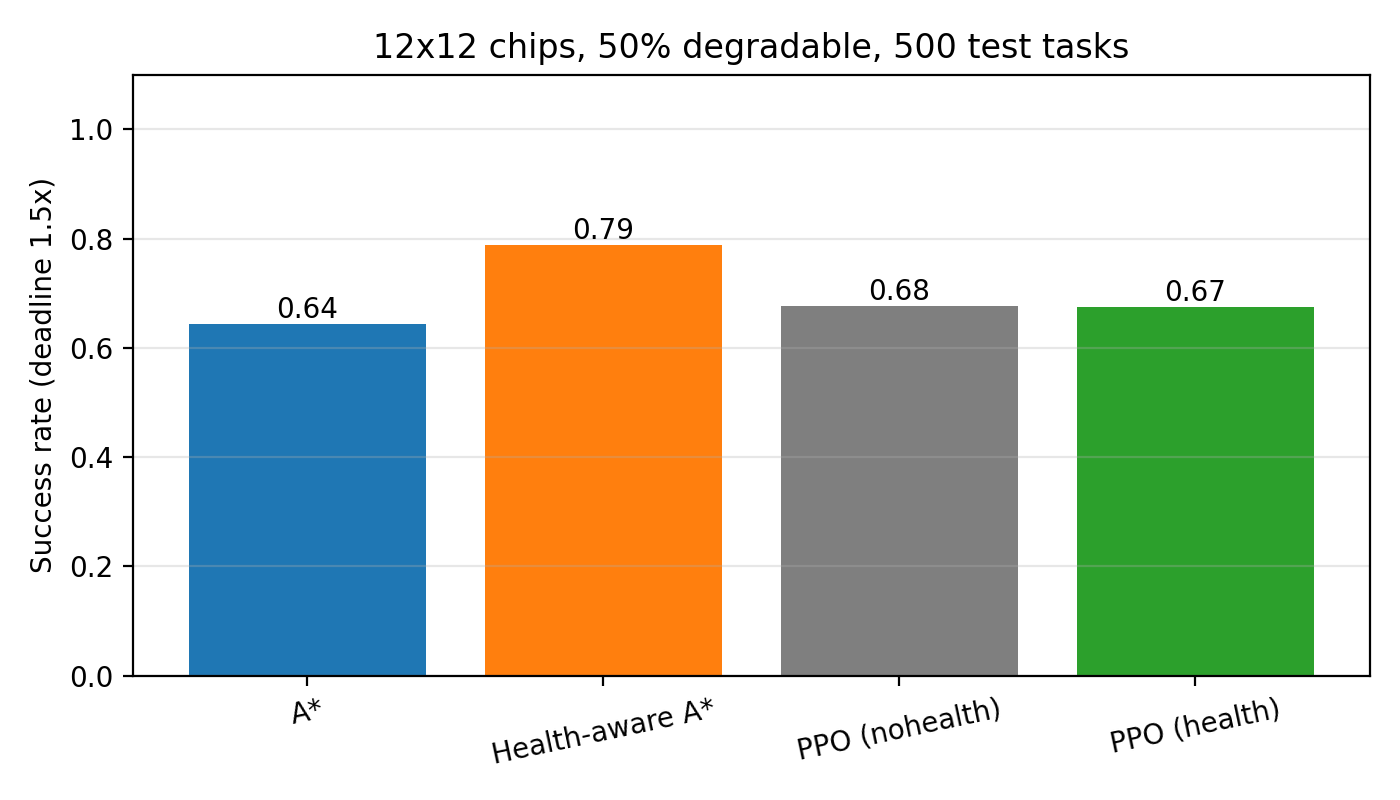

In [7]:
!python experiments/exp4_ppo.py --timesteps 500000
display(Image("results/exp4_learning_curve.png", width=600))
display(Image("results/exp4_eval.png", width=600))

## 7. Download all results

In [8]:
!zip -qr results.zip results
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>